# 1. Título e Identificação da Atividade

**Projeto:** Sistema de Controle de Acesso via Reconhecimento Facial (Desafio Final)  
**Aluno:** Roger Gonçalves dos Santos

# 2. APRESENTAÇÃO DO PROJETO

Este documento propõe a criação de um sistema de controle de acesso na empresa via reconhecimento facial, em substituição ao modelo de crachás físicos e/ou senhas. A importância dessa substituição se deve,  principalmente, à vulnerabilidade dos modelos mais tradicionais, que podem facilmente ser burlados por meios como espionagem, roubo ou compartilhamento indevido, além da praticidade e modernização da biometria facial.  

# 3. OBJETIVO DO PROJETO

O objetivo é: Um painel fará a leitura facial do rosto do colaborador, onde através da imagem escaneada estabelecerá uma comparação com o banco de dados específico para o setor que está tentando ser acessado. Após a leitura, no painel será retornado o valor "ACESSO AUTORIZADO" ou "ACESSO NEGADO" dependendo do grau de permissão encontrada no banco de dados.

# 4. Importação das Bibliotecas

Nesta etapa, preparamos o ambiente de desenvolvimento importando as ferramentas essenciais para o pipeline de visão computacional e Inteligência Artificial. As bibliotecas selecionadas para este projeto são:

* **OpenCV (`cv2`):** Será utilizado para captura da imagem via câmera e para a parte da detecção facial.
* **DeepFace:** Framework nativo do Python, presente no pacote PyPI. Será o principal motor da IA, responsável por extrair as características faciais da imagem que será recortada e calcular matematicamente a similaridade em comparação com a imagem de referência presente no banco de dados.
* **Matplotlib (`pyplot`):** Utilizada para a renderização gráfica e visualização das imagens diretamente no ambiente do notebook.

In [11]:
# Instalação das bibliotecas
# comando "!pip install deepface opencv-python matplotlib" no google colab

import cv2
from deepface import DeepFace
import matplotlib.pyplot as plt


# 5. Carregamento e Exibição das Imagens
Para os testes de validação do sistema, foram extraídas imagens locais do dataset acadêmico CelebA, que utiliza fotos públicas de celebridades. Carregaremos três imagens para simular o nosso ambiente:
1. A foto oficial do colaborador cadastrada no banco de dados.
2. Uma foto do mesmo colaborador capturada pela câmera da portaria (cenário de acesso autorizado).
3. Uma foto de um indivíduo não cadastrado (cenário de invasor/acesso negado).

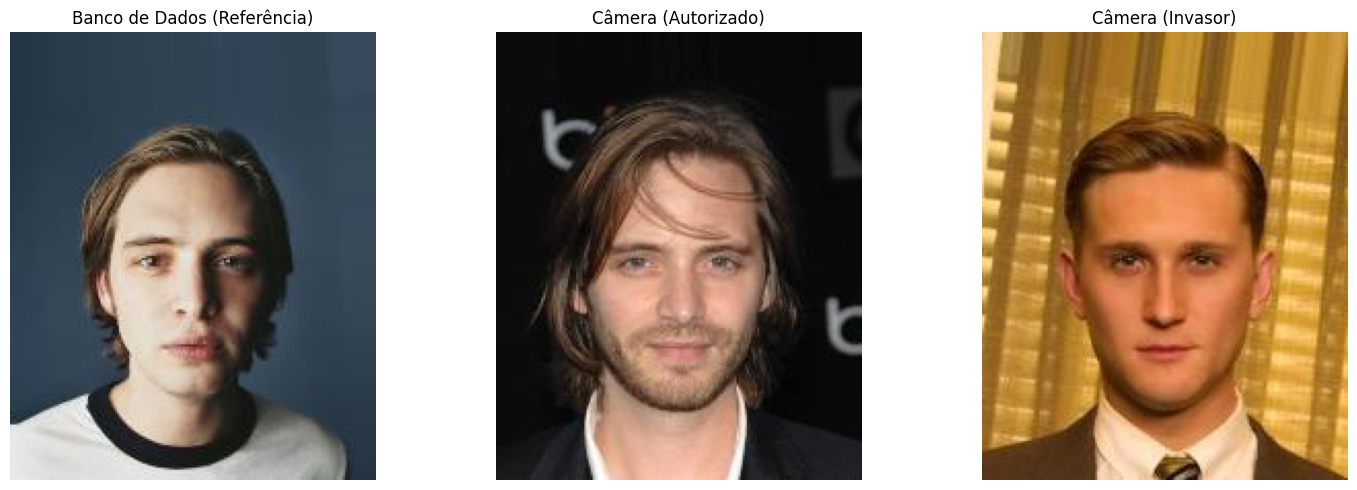

In [12]:

# 1. Ajustando para ler os arquivos no mesmo diretório do notebook
func_referencia = "referencia.jpg"
func_autorizado = "autorizado.jpg"
invasor = "invasor.jpg"
     
# Carregando as imagens usando o OpenCV
img_ref = cv2.imread(func_referencia)
img_auth = cv2.imread(func_autorizado)
img_invader = cv2.imread(invasor)

# O OpenCV lê imagens no formato BGR, mas o Matplotlib exibe em RGB.
img_ref_rgb = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)
img_auth_rgb = cv2.cvtColor(img_auth, cv2.COLOR_BGR2RGB)
img_invader_rgb = cv2.cvtColor(img_invader, cv2.COLOR_BGR2RGB)

# Configurando a exibição visual das imagens lado a lado
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_ref_rgb)
axes[0].set_title("Banco de Dados (Referência)")
axes[0].axis('off')

axes[1].imshow(img_auth_rgb)
axes[1].set_title("Câmera (Autorizado)")
axes[1].axis('off')

axes[2].imshow(img_invader_rgb)
axes[2].set_title("Câmera (Invasor)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 6. Comparação facial com DeepFace ou abordagem equivalente
Nesta etapa, utilizamos o framework DeepFace para processar as imagens carregadas. O modelo atua extraindo os *embeddings* faciais (vetores numéricos que representam as características únicas do rosto) e calcula a distância matemática entre eles. Como definimos uma arquitetura de Verificação 1:1 com a estratégia de *early return*, ou seja, pós validação prévia, essa validação biométrica só é acionada após o sistema confirmar que a credencial digitada existe no banco de dados, otimizando os recursos computacionais.

In [ ]:
# Seção 6: Comparação facial com DeepFace ou abordagem equivalente
import time
from cv2 import threshold

def avaliar_cenario(nome_cenario, path1, path2):
    
   # Função para realizar a verificação biométrica entre duas imagens.

    print(f"Processando: {nome_cenario}")
    try:
        # Enforce detection = True para garantir que há rostos nas fotos.
        resultado = DeepFace.verify(
            img1_path=path1,
            img2_path=path2,
            model_name="VGG-Face",
            enforce_detection=True
        )
        
        distancia = resultado['distance']
        is_verified = resultado['verified']

        # Feedback textual detalhado no console
        print(f"Concluído. Distância: {distancia:.4f} | Mesma pessoa: {is_verified}")
        
        print("-" * 40)
        if is_verified:
            print(f"ACESSO AUTORIZADO")
            print(f"Identidade confirmada com sucesso.")
        else:
            print(f"ACESSO NEGADO")
            print("Biometria divergente detectada.")

        return resultado

    except Exception as e:
        print(f"Erro no processamento: {e}")
        return None


# Função para testar os cenários de reconhecimento facial

def testar_cenarios():
    print("Testando sistema de reconhecimento facial\n")
    inicio_total = time.time()

    # Reutilizamos as variáveis definidas na  seção 5
    
    # Criamos o cenário autorizado
    resultado_ia_auth = avaliar_cenario(
        "CENÁRIO 1 - Funcionário Autorizado na Portaria",
        func_referencia, func_autorizado)
    
    # Criamos o cenário do invasor
    resultado_ia_invader = avaliar_cenario(
        "CENÁRIO 2 - Invasor não cadastrado na Portaria",
        func_referencia, invasor)

    tempo_total = time.time() - inicio_total
    print(f"Teste finalizado. Tempo Total: {tempo_total:.2f} segundos")
    
    # Retornamos os resultados para serem utilizadas nas seções 7 e 8
    return resultado_ia_auth, resultado_ia_invader


resultado_ia_auth, resultado_ia_invader = testar_cenarios()



Testando sistema de reconhecimento facial

Processando: CENÁRIO 1 - Funcionário Autorizado na Portaria
Concluído. Distância: 0.6785 | Mesma pessoa: True
----------------------------------------
ACESSO AUTORIZADO
Identidade confirmada com sucesso.
Erro no processamento: Invalid format specifier '= resultado['threshold']' for object of type 'float'
Processando: CENÁRIO 2 - Invasor não cadastrado na Portaria
Concluído. Distância: 0.8754 | Mesma pessoa: False
----------------------------------------
ACESSO NEGADO
Biometria divergente detectada.
Teste finalizado. Tempo Total: 0.87 segundos


# 7. Classificação e decisão de acesso

Com a distância biométrica calculada pelo DeepFace, o sistema aplica a lógica binária de controle de acesso industrial. O programa interpreta o valor booleano retornado pela IA (`True` ou `False`) e o traduz em uma ação física e visual na portaria. Se as identidades coincidirem (distância abaixo do limiar), o acesso é liberado; caso contrário, o protocolo de segurança é acionado.

In [9]:
# Aplicando a regra de negócio com base na resposta estruturada da IA
print("=" * 50)
print("       SISTEMA DE CONTROLE DE ACESSO")
print("=" * 50)

def avaliar_cenario(resultado, cenario):
    
    if resultado['verified'] == True:
        print(f"{cenario}\nACESSO AUTORIZADO")
        print("Identidade confirmada com sucesso. Acesso liberado.")
      
    else:
        print(f"{cenario}\nACESSO NEGADO")
        print("Biometria divergente detectada. Acesso negado.")
            

# Avaliando Cenário 1
avaliar_cenario(resultado_ia_auth, "CENÁRIO 1 - Funcionário autorizado")


# Avaliando Cenário 2
avaliar_cenario(resultado_ia_invader, "CENÁRIO 2 - Invasor não cadastrado na Portaria")
print("\n" + "=" * 50)

       SISTEMA DE CONTROLE DE ACESSO
CENÁRIO 1 - Funcionário autorizado
ACESSO AUTORIZADO
Identidade confirmada com sucesso. Acesso liberado.
CENÁRIO 2 - Invasor não cadastrado na Portaria
ACESSO NEGADO
Biometria divergente detectada. Acesso negado.



# 8. Feedback visual ou textual
Para garantir que o sistema seja intuitivo para os operadores de segurança física, esta etapa traduz o retorno lógico da IA em um feedback visual. Utilizando as funções de desenho do OpenCV, aplicamos sobre a imagem capturada pela câmera o texto com o valor retornado e uma borda de sinalização verde para acessos permitidos e vermelho para acessos bloqueados.

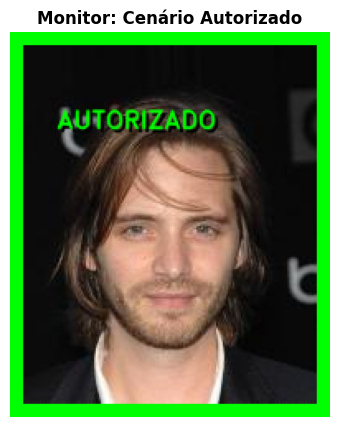

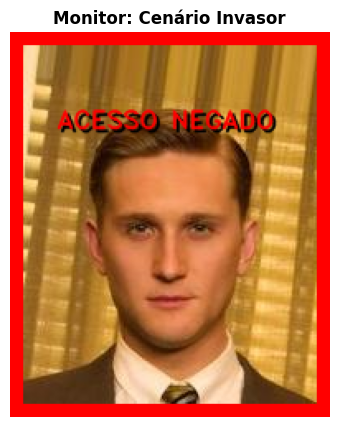

In [ ]:

# --- Definição da Função de Feedback Visual ---
def exibir_monitor_portaria(caminho_imagem, resultado_ia, titulo_cenario):
    
   # Gera o feedback visual (borda e texto) na imagem da câmara com base no resultado real da IA para aquele cenário.
   
    # 1. Carrega a imagem correspondente
    img_visual = cv2.imread(caminho_imagem)
    img_visual_rgb = cv2.cvtColor(img_visual, cv2.COLOR_BGR2RGB)

    # 2. Define a cor e o texto com base no dicionário correto da IA
    if resultado_ia['verified'] == True:
        cor = (0, 255, 0) # cor verde na escala RGB
        texto = "AUTORIZADO"
    else:
        cor = (255, 0, 0) # cor vermelha na escala RGB
        texto = "ACESSO NEGADO"

    # 3. Configurações de desenho do OpenCV
    fonte = cv2.FONT_HERSHEY_DUPLEX
    tamanho_fonte = 0.5
    espessura_linha = 1

    # Escreve o texto com uma leve sombra preta para garantir a leitura
    cv2.putText(img_visual_rgb, texto, (22, 52), fonte, tamanho_fonte, (0, 0, 0), espessura_linha, cv2.LINE_AA)
    cv2.putText(img_visual_rgb, texto, (20, 50), fonte, tamanho_fonte, cor, espessura_linha, cv2.LINE_AA)

    # Aplica a borda colorida na imagem inteira
    espessura_borda = 8
    img_com_borda = cv2.copyMakeBorder(
        img_visual_rgb, 
        top=espessura_borda, bottom=espessura_borda, left=espessura_borda, right=espessura_borda, 
        borderType=cv2.BORDER_CONSTANT, 
        value=cor
    )

    # 4. Exibindo o resultado final
    plt.figure(figsize=(6, 5))
    plt.imshow(img_com_borda)
    plt.axis('off')
    plt.title(titulo_cenario, fontsize=12, fontweight="bold")
    plt.show()


# --- Execução Automatizada para os Dois Cenários ---

# Cenário 1: Exibir o Funcionário Autorizado (Deve mostrar Verde / AUTORIZADO)
exibir_monitor_portaria(func_autorizado, resultado_ia_auth, "Monitor: Cenário Autorizado")

# Cenário 2: Exibir o Invasor (Deve mostrar Vermelho / ACESSO NEGADO)
exibir_monitor_portaria(invasor, resultado_ia_invader, "Monitor: Cenário Invasor")

# 9. Análise dos Resultados

A implementação prática do modelo de IA demonstrou a eficácia do controle de acesso baseado em biometria facial aliado à autenticação multifator (MFA). O sistema foi capaz de interpretar e distinguir com precisão os dois cenários propostos:

* **Cenário de Acesso Autorizado:** Ao processar a imagem do funcionário legítimo previamente validado pela credencial, o algoritmo calculou uma distância biométrica inferior ao limiar (*threshold*) do modelo. Isso atestou a similaridade das faces, resultando na liberação sistêmica e no feedback visual verde de "AUTORIZADO".
* **Cenário de Invasão:** Ao confrontar a foto de referência com a face de um indivíduo não cadastrado, a distância matemática extraída pelas características faciais foi significativamente superior ao limite de tolerância. O sistema identificou imediatamente a divergência, mantendo o bloqueio e gerando o feedback visual vermelho de "ACESSO NEGADO".

# 10. DESAFIOS E LIMITAÇÕES

Os principais desafios técnicos para a implementação dessa solução são variáveis que muitas vezes não podem ser controladas, como variação de iluminação do ambiente e obstruções faciais, como uso de óculos, máscaras ou chapéus/bonés. Em questão de segurança, um possível invasor poderia utilizar uma foto, seja ela impressa ou em algum aparelho eletrônico para burlar a verificação, sendo necessária uma futura implementação de um algoritmo de prova de vida, conhecido como liveness detection(ex: a necessidade de piscar os olhos uma determinada quantidade de vezes para que a verificação seja completa).

# 11. REFLEXÃO FINAL

A proposta do projeto deixa claro que, para a aplicação deste algoritmo e de qualquer outro que lide com dados e informações de pessoais reais, é necessário não só a eficiência do algoritmo, como o cuidado e alinhamento com as políticas de segurança da informação, dada a sensibilidade destes dados. O maior aprendizado a ser retirado dessa fase é compreender que a inovação tecnológica é tão importante quanto a mitigação dos riscos e respeito à privacidade dos que serão submetidos ao algoritmo.

# 12. Referências ou materiais consultados

* Material Didático do Curso (Cap. 1, pág. 9 a 24; Cap. 2, pág. 29 a 40; Cap. 3, pág. 45 a 52).
* Documentação Oficial do OpenCV. Disponível em: https://docs.opencv.org/
* Repositório Oficial do DeepFace (Framework para reconhecimento facial em Python). Disponível em: https://github.com/serengil/deepface
* Documentação Oficial do Matplotlib (Utilizado para a renderização do feedback visual). Disponível em: https://matplotlib.org/
* Liu, Z., Luo, P., Wang, X., & Tang, X. "Large-scale CelebFaces Attributes (CelebA) Dataset". Disponível em: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
